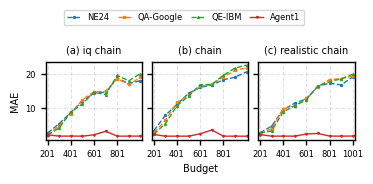

In [4]:
import pandas as pd
import matplotlib.pyplot as plt

# -----------------------------
# Inputs
# -----------------------------
PANELS = [
    ("(a) iq chain", "exp02_summary_mean_abs_error_vs_budget_iq_chain_nl0.05.csv"),
    ("(b) chain", "exp02_summary_mean_abs_error_vs_budget_chain_nl0.05.csv"),
    ("(c) realistic chain", "exp02_summary_mean_abs_error_vs_budget_realistic_chain_nl0.05.csv"),
]

# Approx IJCAI single-column width (inches). If your template differs, set this to \columnwidth.
COL_IN = 3.45
# Height tuned for 1x3 subplots + legend on top
H_IN = 1.70

OUT_PNG = "exp03_ijcai_singlecol_budget_legend_top.png"
OUT_PDF = "exp03_ijcai_singlecol_budget_legend_top.pdf"

# Optional: per-method linestyle
LINESTYLES = {
    # Example: use dashed lines for v1 variants
    "NE24": "--",
    "QA-Google": "--",
    "QE-IBM": "--",
    # "Agent1": "--",
}

# Legend ordering (optional). Any missing methods will be appended.
METHOD_ORDER = [
    "NE24",
    "QA-Google",
    "QE-IBM",
    "Agent1",
]

# Marker cycle (no fixed colors; matplotlib default color cycle will be used)
MARKERS = ["o", "s", "^", "v", "D", "P", "X", "+", "*"]

# -----------------------------
# Plot style (IJCAI-friendly)
# -----------------------------
plt.rcParams.update(
    {
        "font.size": 7,
        "axes.labelsize": 7,
        "axes.titlesize": 7,
        "legend.fontsize": 6,
        "xtick.labelsize": 6,
        "ytick.labelsize": 6,
        "lines.linewidth": 1,
        "lines.markersize": 1.4,
        "axes.linewidth": 1.0,
        "xtick.major.width": 1.0,
        "ytick.major.width": 1.0,
        "xtick.major.size": 3.5,
        "ytick.major.size": 3.5,
    }
)


def load_wide_csv(path: str):
    """CSV format: rows=method, columns=x-values (as strings)."""
    df = pd.read_csv(path)

    x_cols = [c for c in df.columns if c != "method"]
    x = sorted(float(c) for c in x_cols)
    col_of = {float(c): c for c in x_cols}

    series = {}
    for _, row in df.iterrows():
        name = row["method"]
        series[name] = [float(row[col_of[v]]) for v in x]

    return x, series


def ordered_methods(methods):
    ordered = [m for m in METHOD_ORDER if m in methods]
    for m in methods:
        if m not in ordered:
            ordered.append(m)
    return ordered


def choose_ticks(x, max_ticks: int = 5):
    """Pick up to `max_ticks` ticks evenly across x (keeps endpoints)."""
    if len(x) <= max_ticks:
        return x

    n = len(x)
    if max_ticks <= 2:
        return [x[0], x[-1]]

    raw = [i * (n - 1) / (max_ticks - 1) for i in range(max_ticks)]
    idxs = []
    for v in raw:
        j = int(round(v))
        if j not in idxs:
            idxs.append(j)

    # ensure endpoints exist
    if 0 not in idxs:
        idxs = [0] + idxs
    if (n - 1) not in idxs:
        idxs = idxs + [n - 1]

    idxs = sorted(set(idxs))
    return [x[i] for i in idxs]


def is_almost_int(v: float, eps: float = 1e-9) -> bool:
    return abs(v - round(v)) < eps


def main():
    fig, axes = plt.subplots(1, 3, figsize=(COL_IN, H_IN), sharey=True)

    for ax, (title, path) in zip(axes, PANELS):
        x, series = load_wide_csv(path)
        methods = ordered_methods(list(series.keys()))

        for i, m in enumerate(methods):
            ax.plot(
                x,
                series[m],
                marker=MARKERS[i % len(MARKERS)],
                linestyle=LINESTYLES.get(m, "-"),  # 关键：按方法名取线型
                label=m,
            )

        ax.set_title(title)
        ax.grid(True, linestyle="--", alpha=0.35)

        # Dynamic x padding (matches the original 0.002 padding when x-range is 0.1)
        xr = max(x) - min(x)
        pad = 0.02 * xr if xr > 0 else 1.0
        ax.set_xlim(min(x) - pad, max(x) + pad)

        # Reduce tick crowding for IJCAI single-column plots
        ticks = choose_ticks(x, max_ticks=5)

        # Remove the rightmost tick (e.g., 1001) for the first two subplots to avoid overlap
        is_last_subplot = (ax is axes[-1])  # or use index in the loop
        if (not is_last_subplot) and (len(ticks) > 0) and (abs(ticks[-1] - max(x)) < 1e-9):
            ticks = ticks[:-1]

        ax.set_xticks(ticks)
        if all(is_almost_int(t) for t in ticks):
            ax.set_xticklabels([str(int(round(t))) for t in ticks])


    axes[1].set_xlabel("Budget")  # 只保留中间
    axes[0].set_xlabel("")
    axes[2].set_xlabel("")

    axes[0].set_ylabel("MAE")

    # Single legend for the whole figure (moved above all subplots)
    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(
        handles,
        labels,
        loc="upper center",
        bbox_to_anchor=(0.5, 1.05),
        ncol=4,
        frameon=True,
        handlelength=1.6,
        columnspacing=1.0,
        borderpad=0.4,
    )

    # Reserve top space for the legend
    fig.subplots_adjust(left=0.10, right=0.995, bottom=0.26, top=0.72, wspace=0.10)

    fig.savefig(OUT_PNG, dpi=600, bbox_inches="tight", pad_inches=0.02)
    fig.savefig(OUT_PDF, bbox_inches="tight")


if __name__ == "__main__":
    main()
